In [1]:
import pandas as pd
import seaborn as sns
from torch.utils.data import DataLoader, Dataset,  SequentialSampler, TensorDataset, Subset
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import copy
from tqdm import tqdm
import numpy as np
from sklearn.decomposition import PCA
import torch
from torch.nn import CrossEntropyLoss, MSELoss
from functools import partial
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report
import random
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
import gc

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(device)
else:
    print("MPS device not found.")

cuda


In [3]:
model = AutoModelForSequenceClassification.from_pretrained("fabriceyhc/bert-base-uncased-yahoo_answers_topics")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [4]:
class TestDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.sentences = df.iloc[:, 1:].apply(lambda x: ' '.join(x.dropna().astype(str)), axis=1).values
        self.labels = df.iloc[:, 0].values - 1  # Label을 0부터 시작하도록 조정
        self.tokenizer = tokenizer
    def __len__(self):
        return len(self.sentences)
    def __getitem__(self, idx):
        sentence = self.sentences[idx]
        inputs = self.tokenizer(sentence, truncation=True, max_length=512, padding='max_length', return_tensors="pt")
        label = torch.tensor(self.labels[idx])
        return inputs, label

In [5]:
# validation 데이터 가져오기
validation_data = "./validation.csv"
validation_df = pd.read_csv(validation_data, header=None, names=["class","question_title","question_body","answer"])
validation_dataset = TestDataset(validation_df, tokenizer)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False)
# test 데이터 가져오기
test_data = "./test2.csv"
test_df = pd.read_csv(test_data, header=None, names=["class","question_title","question_body","answer"])
test_dataset = TestDataset(test_df, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [6]:
def extract_embeddings(outputs):
    return outputs.hidden_states[0], outputs.hidden_states[-1]

In [7]:
def select_true_example(model, num_labels, data_frame, data_loader, tokenizer, device):
    correct_predictions = [[] for _ in range(num_labels)]
    sorted_input_embeddings = []
    sorted_output_embeddings = []
    class_dfs = []
    batch_start_idx = 0
    for batch in tqdm(data_loader, desc="Evaluating model"):
        inputs, labels = batch
        inputs = {k: v.squeeze(1).to(device) for k, v in inputs.items()}
        labels = labels.to(device)
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
            input_embeddings, output_embeddings = extract_embeddings(outputs)
        predictions = outputs.logits.argmax(dim=-1)
        for i in range(len(labels)):
            if predictions[i] == labels[i]:
                # 올바른 인덱스를 사용하여 데이터프레임의 해당 행을 가져옴
                original_index = batch_start_idx + i
                correct_predictions[labels[i].item()].append((outputs.logits[i, predictions[i]].item(), data_frame.iloc[original_index].tolist(), input_embeddings[i].cpu().numpy(), output_embeddings[i].cpu().numpy()))
        batch_start_idx += len(labels)
    for i in range(num_labels):
        # logit 값에 따라 정렬
        correct_predictions[i].sort(key=lambda x: x[0], reverse=True)
        # 정렬된 데이터를 분리하여 저장
        # sorted_class_data = [pred[1] for pred in correct_predictions[i]]
        sorted_input_embeds = [pred[2] for pred in correct_predictions[i]]
        # sorted_output_embeds = [pred[3] for pred in correct_predictions[i]]
        # 정렬된 데이터를 DataFrame으로 변환
        # class_df = pd.DataFrame(sorted_class_data)
        # class_dfs.append(class_df)
        sorted_input_embeddings.append(sorted_input_embeds)
        # sorted_output_embeddings.append(sorted_output_embeds)
    return sorted_input_embeddings

In [8]:
input_embeds = select_true_example(model, 10, validation_df, validation_loader, tokenizer, device)

Evaluating model: 100%|██████████| 938/938 [03:56<00:00,  3.96it/s]


In [8]:
def extract_top_n_embeddings(extract_num, class_num, embeds_list):
    return_list = []
    for i in range(extract_num):
        extracted_embeds = []
        for j in range(0, class_num):
            class_embeds = np.array(embeds_list[j][i:i+1])
            class_embeds_tensor = torch.tensor(class_embeds)
            extracted_embeds.append(class_embeds_tensor)
        return_list.append(extracted_embeds)
    return return_list

In [9]:
def extract_bottom_n_embeddings(extract_num, class_num, embeds_list):
    return_list = []
    for i in range(extract_num):
        extracted_embeds = []
        for j in range(class_num):
            class_embeds = np.array(embeds_list[j][-(i+1):-(i)] or embeds_list[j][-(i+1):])
            class_embeds_tensor = torch.tensor(class_embeds)
            extracted_embeds.append(class_embeds_tensor)
        return_list.append(extracted_embeds)
    return return_list

In [11]:
extract_embed_list=[]
extract_embed_list.extend(extract_top_n_embeddings(4, 10, input_embeds))
extract_embed_list.extend(extract_bottom_n_embeddings(0, 10, input_embeds))

In [10]:
def get_decimal_precision(value):
    str_value = str(value)
    if '.' in str_value:
        return len(str_value.split('.')[1])
    else:
        return 0

In [11]:
def perturb(embeds, eps, grad):
    perturbed_embeds = embeds - eps*grad.sign()
    return perturbed_embeds

In [21]:
def calculate_gradient(model, input_embeds, target_class, device):
    print(input_embeds.shape)
    input_embeds = input_embeds.clone().detach().requires_grad_(True).to(device)
    target = torch.tensor([target_class]).to(device)
    outputs = model(inputs_embeds=input_embeds, labels=target)
    init_pred = outputs.logits.argmax(dim=-1)
    loss = outputs.loss
    model.zero_grad()
    loss.backward()
    data_grad = input_embeds.grad
    return loss, data_grad

In [13]:
def fgsm_attack(model, source, target, input_embeds, start_eps, eps_step, max_eps, device):
    input_embeds = input_embeds.to(device)
    digits = get_decimal_precision(eps_step)
    targeted_eps = start_eps
    loss, data_grad = calculate_gradient(model, input_embeds, target, device)
    first_diff_eps = math.inf
    
    while targeted_eps <= max_eps:
        # print(f"epsilon : {eps}")
        perturbed_embeds = perturb(input_embeds, targeted_eps, data_grad)
        adv_outputs = model(inputs_embeds = perturbed_embeds)
        adv_pred = adv_outputs.logits.argmax(dim=-1)
        # print(adv_pred)

        if first_diff_eps == math.inf and adv_pred.item() != source:
            first_diff_eps = targeted_eps
        
        if adv_pred.item() == target:
            # print(f"{eps} adv attack success!")
            # print()
            break
        else:
            targeted_eps += eps_step
            targeted_eps = round(targeted_eps, digits)
            # print()
    return targeted_eps, first_diff_eps

In [16]:
def calculate_all_epsilon(model, class_num, logit_example, step_eps=0.01, max_eps=10.0):
    first_changed_list = []
    targeted_list = []
    for i in range(0, class_num):
        print(f"class {i}")
        targeted_temp = []
        first_changed_temp = []
        for j in range(0, class_num):
            if i == j:
                targeted_temp.append((i, j, math.inf))
                first_changed_temp.append((i, j, math.inf))
                continue
            eps, first_diff_eps = fgsm_attack(model, i, j, logit_example[i], 0.00, step_eps, max_eps, device)
            if eps >= max_eps:
                targeted_temp.append((i, j, math.inf))
            else:
                targeted_temp.append((i, j, eps))
            first_changed_temp.append((i, j, first_diff_eps))
        targeted_list.append(targeted_temp)
        first_changed_list.append(first_changed_temp)
        
    flat_targeted_list = [(source, target, eps) for sublist in targeted_list for source, target, eps in sublist if eps != math.inf]
    flat_first_changed_list = [(source, target, eps) for sublist in first_changed_list for source, target, eps in sublist if eps != math.inf and eps - (2*step_eps) >=0.00]
        
    return flat_targeted_list, flat_first_changed_list

In [15]:
def calculate_all_epsilon(model, class_num, logit_example, step_eps=0.01, max_eps=10.0):
    first_changed_list = []
    targeted_list = []
    for i in range(0, class_num):
        #print(f"class {i}")
        targeted_temp = []
        first_changed_temp = []
        for j in range(0, class_num):
            if i == j:
                targeted_temp.append((i, j, math.inf))
                first_changed_temp.append((i, j, math.inf))
                continue
            eps, first_diff_eps = fgsm_attack(model, i, j, logit_example[i], 0.00, step_eps, max_eps, device)
            if eps >= max_eps:
                targeted_temp.append((i, j, math.inf))
            else:
                targeted_temp.append((i, j, eps))
            first_changed_temp.append((i, j, first_diff_eps))
        targeted_list.append(targeted_temp)
        first_changed_list.append(first_changed_temp)
        
    flat_targeted_list = [(source, target, eps) for sublist in targeted_list for source, target, eps in sublist if eps != math.inf]
    flat_first_changed_list = [(source, target, eps) for sublist in first_changed_list for source, target, eps in sublist if eps != math.inf and eps - step_eps >=0.00]
        
    return flat_targeted_list, flat_first_changed_list

In [28]:
negative_eps = []
positive_eps = []

for i in range(0, len(extract_embed_list)):
    targeted_eps, first_changed_eps = calculate_all_epsilon(model, 10, extract_embed_list[i], 0.01, 5.00)
    positive_eps.append(first_changed_eps)
    negative_eps.append(targeted_eps)

NameError: name 'intput_embeds' is not defined

In [17]:
def generate_example(model, device, source, target, input_embeds, example_num, boundary_eps, step_eps):
    example_list = []
    example_label = []
    source_embedding = input_embeds[source].to(device)
    # Gradient 계산
    loss, data_grad = calculate_gradient(model, source_embedding, target, device)
    iter_num = 0
    while iter_num < example_num:
        # Perturbation 적용
        # eps = boundary_eps + random.uniform(eps_range_start, eps_range_end)
        eps = random.uniform(boundary_eps, boundary_eps + step_eps) 
        generated_embeds = perturb(source_embedding, eps, data_grad)
        example_list.append(generated_embeds.cpu())  # CPU로 이동
        example_label.append(source)
        iter_num += 1
        del generated_embeds
        torch.cuda.empty_cache()  # GPU 메모리 캐시 비우기
    del source_embedding, loss, data_grad
    torch.cuda.empty_cache()  # 캐시 비우기
    return example_label, example_list

In [18]:
def adjust_examples(example_list, example_label, eps_list, embed_list, target_num, step_eps, generate_fn, model, device):
    if len(example_list) < target_num:
        diff = target_num - len(example_list)
        for _ in range(diff):
            random_index = random.randint(0, len(embed_list)-1)
            input_embed = embed_list[random_index]
            eps_values = eps_list[random_index]
            if eps_values:  # eps_values가 존재하는 경우에만 진행
                source, target, eps = random.choice(eps_values)
                label, example = generate_fn(model, device, source, target, input_embed, 1, eps-2*step_eps, step_eps)
                example_label.extend(label)
                example_list.extend(example)
    elif len(example_list) > target_num:
        diff = len(example_list) - target_num
        for _ in range(diff):
            random_index = random.randint(0, len(example_list) - 1)
            example_list.pop(random_index)
            example_label.pop(random_index)

In [19]:
def make_example(model, data_frame, data_loader, tokenizer, example_num, top_emb, bottom_emb, class_num, true_ratio, device, step_eps=0.01, max_eps=10.0):
    extract_embed_list = []
    negative_eps = []
    positive_eps = []
    positive_example_list = []
    positive_example_label = []
    negative_example_list = []
    negative_example_label = []
    # Positive, Negative 예제 개수 계산

    positive_num = int(round(example_num * true_ratio*0.01))
    negative_num = example_num - positive_num
    extract_num = top_emb + bottom_emb

    print("Generate positive num : ", positive_num)
    print("Generate negative num : ", negative_num)
    
    per_emb_positive_example_num = int(round(positive_num / extract_num))
    per_emb_negative_example_num = int(round(negative_num / extract_num))

    print("Extract Num : ", extract_num)
    print("Generate per embedding positive example num : ", per_emb_positive_example_num)
    print("Generate per embedding negative example num : ", per_emb_negative_example_num)

    input_embeds = select_true_example(model, class_num, data_frame, data_loader, tokenizer, device)
    
    extract_embed_list.extend(extract_top_n_embeddings(top_emb, class_num, input_embeds))
    extract_embed_list.extend(extract_bottom_n_embeddings(bottom_emb, class_num, input_embeds))

    for i in range(0, len(extract_embed_list)):
        targeted_eps, first_changed_eps = calculate_all_epsilon(model, class_num, extract_embed_list[i], step_eps, max_eps)
        positive_eps.append(first_changed_eps)
        negative_eps.append(targeted_eps)
        
    for i, input_embed in enumerate(extract_embed_list):
        for j, first_changed in enumerate(positive_eps[i]):
            per_positive_example_num = int(round(per_emb_positive_example_num / len(positive_eps[i])))
            source, target, eps = first_changed
            print("per positive example num", per_positive_example_num)
            pos_label, pos_example = generate_example(model, device, source, target, extract_embed_list[i], per_positive_example_num, eps-2*step_eps, step_eps)
            positive_example_label.extend(pos_label)
            positive_example_list.extend(pos_example)

        for j, targeted in enumerate(negative_eps[i]):
            per_negative_example_num = int(round(per_emb_negative_example_num / len(negative_eps[i])))
            source, target, eps = targeted
            print("per negative example num", per_negative_example_num)
            neg_label, neg_example = generate_example(model, device, source, target, extract_embed_list[i], per_negative_example_num, eps, step_eps)
            negative_example_label.extend(neg_label)
            negative_example_list.extend(neg_example)

    adjust_examples(positive_example_list, positive_example_label, positive_eps, extract_embed_list, positive_num, step_eps, generate_example, model, device)
    adjust_examples(negative_example_list, negative_example_label, negative_eps, extract_embed_list, negative_num, step_eps, generate_example, model, device)
    return positive_example_label, positive_example_list, negative_example_label, negative_example_list

In [23]:
def make_example2(model, data_frame, data_loader, tokenizer, example_num, top_emb, bottom_emb, class_num, device, step_eps=0.01, max_eps=10.0):
    extract_embed_list = []
    negative_eps = []
    positive_eps = []
    example_list = []
    example_label = []
    # Positive, Negative 예제 개수 계산
    extract_num = top_emb + bottom_emb

    print("Generate num : ", example_num)
    
    per_emb_example_num = int(round(example_num / extract_num))

    print("Extract Num : ", extract_num)
    print("Generate embedding positive example num : ", per_emb_example_num)

    input_embeds = select_true_example(model, class_num, data_frame, data_loader, tokenizer, device)
    
    extract_embed_list.extend(extract_top_n_embeddings(top_emb, class_num, input_embeds))
    extract_embed_list.extend(extract_bottom_n_embeddings(bottom_emb, class_num, input_embeds))

    for i in range(0, len(extract_embed_list)):
        targeted_eps, first_changed_eps = calculate_all_epsilon(model, class_num, extract_embed_list[i], step_eps, max_eps)
        positive_eps.append(first_changed_eps)
        negative_eps.append(targeted_eps)
        
    for i, input_embed in enumerate(extract_embed_list):
        for j, first_changed in enumerate(positive_eps[i]):
            per_example_num = int(round(per_emb_example_num / len(positive_eps[i])))
            source, target, eps = first_changed
            print("per example num", per_example_num)
            pos_label, pos_example = generate_example(model, device, source, target, extract_embed_list[i], per_example_num, eps-step_eps, step_eps)
            example_label.extend(pos_label)
            example_list.extend(pos_example)
    adjust_examples(example_list, example_label, positive_eps, extract_embed_list, example_num, step_eps, generate_example, model, device)

    return example_label, example_list

In [24]:
example_label, example_list = make_example2(model, data_frame = validation_df, data_loader = validation_loader, tokenizer = tokenizer, example_num=3000 ,top_emb=2, bottom_emb=2, class_num=10, device=device, step_eps=0.01, max_eps=10.0)

Generate num :  3000
Extract Num :  4
Generate embedding positive example num :  750


Evaluating model: 100%|██████████| 938/938 [02:10<00:00,  7.20it/s]


class 0
class 1
class 2
class 3
class 4
class 5
class 6
class 7
class 8
class 9
class 0
class 1
class 2
class 3
class 4
class 5
class 6
class 7
class 8
class 9
class 0
class 1
class 2
class 3
class 4
class 5
class 6
class 7
class 8
class 9
class 0
class 1
class 2
class 3
class 4
class 5
class 6
class 7
class 8
class 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example num 9
per example nu

In [40]:
# make_example_2 : decision boundary 근처에서 예시 생성
report = ret_classification_report(example_list, example_label)
print(report)

Evaluating: 100%|██████████| 3069/3069 [00:30<00:00, 101.39it/s]


              precision    recall  f1-score   support

           0       0.63      0.52      0.57       783
           1       0.36      0.56      0.44       162
           2       0.38      0.54      0.44       153
           3       0.49      0.40      0.44       540
           4       0.61      0.41      0.49       162
           5       0.74      0.33      0.46       414
           6       0.60      0.52      0.56       162
           7       0.18      0.55      0.27       144
           8       0.42      0.33      0.37       387
           9       0.30      0.57      0.39       162

    accuracy                           0.45      3069
   macro avg       0.47      0.47      0.44      3069
weighted avg       0.52      0.45      0.46      3069



In [22]:
positive_example_label, positive_example_list, negative_example_label, negative_example_list = make_example(model, data_frame = validation_df, data_loader = validation_loader, tokenizer = tokenizer, example_num=3000, top_emb=4, bottom_emb=0, class_num=10, true_ratio=90, device=device, step_eps=0.01, max_eps=10.0)

Generate positive num :  2700
Generate negative num :  300
Extract Num :  4
Generate per embedding positive example num :  675
Generate per embedding negative example num :  75


Evaluating model: 100%|██████████| 938/938 [03:24<00:00,  4.60it/s]


class 0
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
class 1
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
class 2
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
class 3
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
torch.Size([1, 512, 768])
class 4
torch.Size([1, 512, 768]

In [29]:
# make_example_1 : positive, negative 나누어 예시 생성
report = ret_classification_report(positive_example_list, positive_example_label)
print(report)

Evaluating: 100%|██████████| 2700/2700 [00:16<00:00, 163.31it/s]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1041
           1       1.00      1.00      1.00        81
           2       1.00      1.00      1.00       153
           3       1.00      0.74      0.85       493
           4       1.00      1.00      1.00        96
           5       1.00      1.00      1.00       161
           6       1.00      1.00      1.00       160
           7       0.46      1.00      0.63       107
           8       1.00      1.00      1.00       246
           9       1.00      1.00      1.00       162

    accuracy                           0.95      2700
   macro avg       0.95      0.97      0.95      2700
weighted avg       0.98      0.95      0.96      2700



In [30]:
# make_example_1 : positive, negative 나누어 예시 생성
report = ret_classification_report(negative_example_list, negative_example_label)
print(report)

Evaluating: 100%|██████████| 300/300 [00:01<00:00, 211.76it/s]

              precision    recall  f1-score   support

           0       0.05      0.07      0.06        30
           1       0.00      0.00      0.00        26
           2       0.08      0.10      0.09        30
           3       0.00      0.00      0.00        29
           4       0.00      0.00      0.00        29
           5       0.03      0.04      0.04        26
           6       0.30      0.08      0.12        39
           7       0.00      0.00      0.00        30
           8       0.07      0.07      0.07        29
           9       0.00      0.00      0.00        32

    accuracy                           0.04       300
   macro avg       0.05      0.04      0.04       300
weighted avg       0.06      0.04      0.04       300



In [32]:
all_list =  positive_example_list + negative_example_list
all_label = positive_example_label + negative_example_label
report = ret_classification_report(all_list, all_label)
print(report)

Evaluating: 100%|██████████| 3000/3000 [00:14<00:00, 212.94it/s]

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1071
           1       0.72      0.76      0.74       107
           2       0.83      0.85      0.84       183
           3       0.90      0.70      0.79       522
           4       0.86      0.77      0.81       125
           5       0.84      0.87      0.85       187
           6       0.96      0.82      0.88       199
           7       0.39      0.78      0.52       137
           8       0.91      0.90      0.91       275
           9       0.83      0.84      0.83       194

    accuracy                           0.86      3000
   macro avg       0.82      0.83      0.81      3000
weighted avg       0.88      0.86      0.87      3000



In [26]:
def ret_classification_report(emb_list, label_list):
    predictions = []
    with torch.no_grad():
        for i, input_embeds in tqdm(enumerate(emb_list), total=len(emb_list), desc="Evaluating"):
            outputs = model(inputs_embeds=input_embeds.to(device))
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)
            predictions.extend(preds.cpu().numpy())
        report = classification_report(np.array(label_list), predictions)
    return report

In [27]:
def extract_cls_token(model, embedding_list, device):
    cls_token_list = []
    preds_list = []
    for input_embeds in embedding_list:
        # input_embeds = torch.tensor(input_embeds)
        input_embeds = input_embeds.to(device)

        with torch.no_grad():
            outputs = model(inputs_embeds=input_embeds, output_hidden_states=True)
        preds = outputs.logits.argmax(dim=-1)

        cls_token_embed = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
        cls_token_list.extend(cls_token_embed)
        preds_list.append(preds.item())
    return np.array(cls_token_list), preds_list

In [28]:
def select_random_samples(token_list, num_samples=10):
    return random.sample(token_list, num_samples)

In [29]:
def visualize_embeddings(original_cls_token_list, predict_token_list, class_num, random_state=42):    
    tsne = TSNE(n_components=2, random_state=random_state)
    reduced_embeddings = tsne.fit_transform(original_cls_token_list)
    
    # 시각화: 클래스별로 색깔이 구분되도록 함
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=predict_token_list, cmap='tab10', edgecolor='k', s=40)
    
    # 범례 생성
    handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
    legend_labels = [f"class {i+1}" for i in range(class_num)]
    #legend_labels = ['Top1', 'Top2', 'Bottom2', 'Bottom1']
    legend = plt.legend(handles, legend_labels, title="Classes")
    
    # 제목 및 축 레이블 설정
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    
    # 시각화 출력
    plt.show()

In [31]:
plot_list = []
plot_list.extend(extract_top_n_embeddings(500, 10, input_embeds))

In [32]:
exp = []
for i in range(500):
    for j in range(10):
        exp.append(plot_list[i][j])

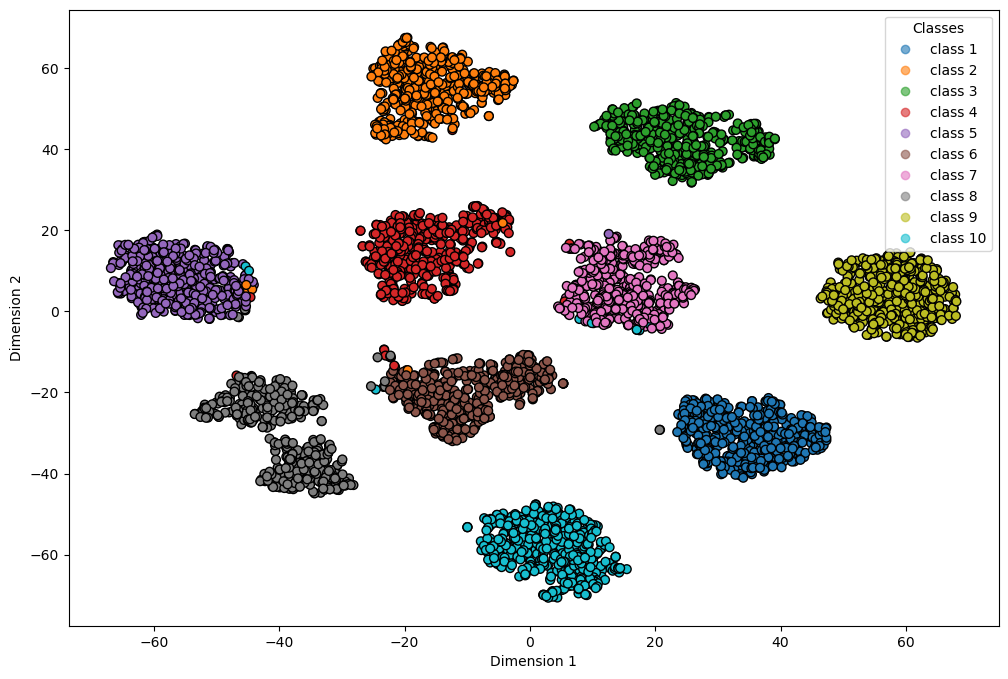

In [92]:
cls_list, preds_list = extract_cls_token(model, exp, device)
visualize_embeddings(cls_list, preds_list, 10, random_state=42)

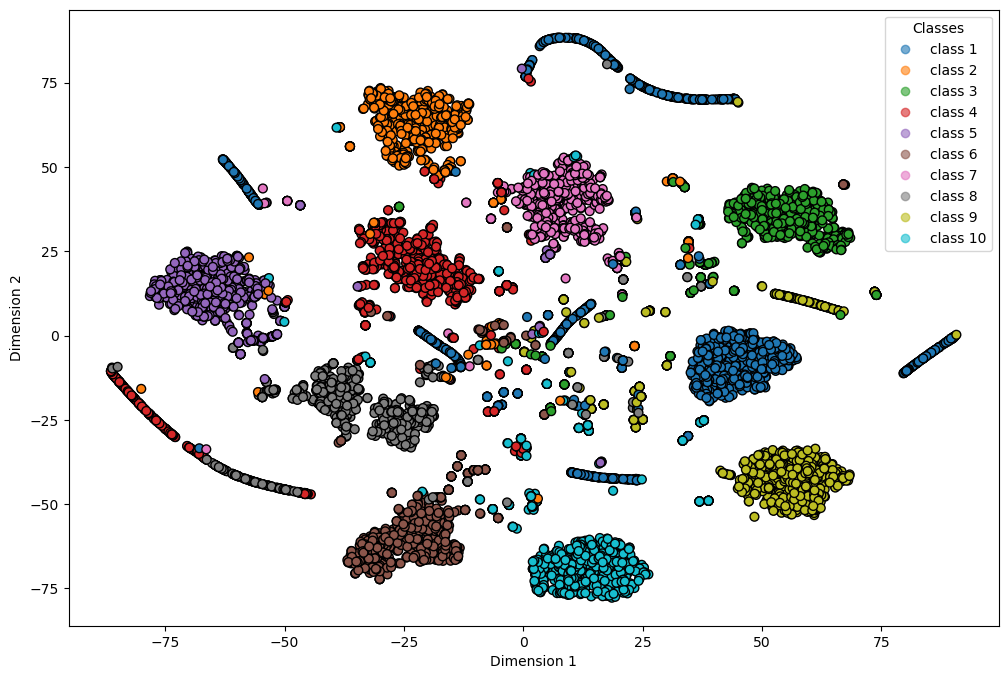

In [77]:
all_list = exp+positive_example_list+negative_example_list
cls_list, preds_list = extract_cls_token(model, all_list, device)
visualize_embeddings(cls_list, preds_list, 10, random_state=42)

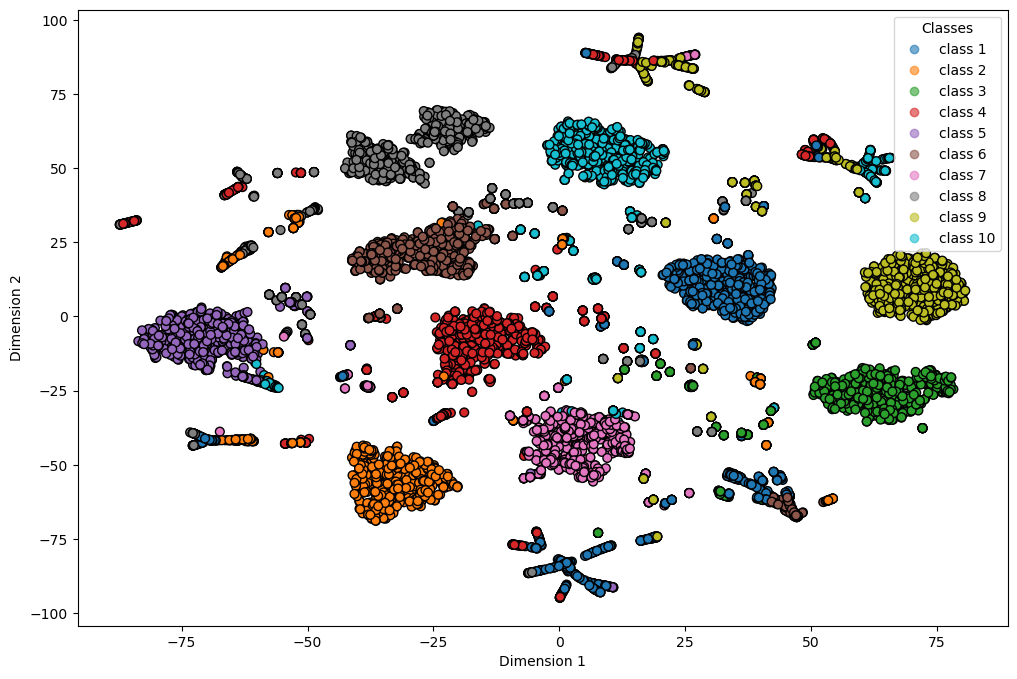

In [81]:
all_list = exp + example_list
cls_list, preds_list = extract_cls_token(model, all_list, device)
visualize_embeddings(cls_list, preds_list, 10, random_state=42)

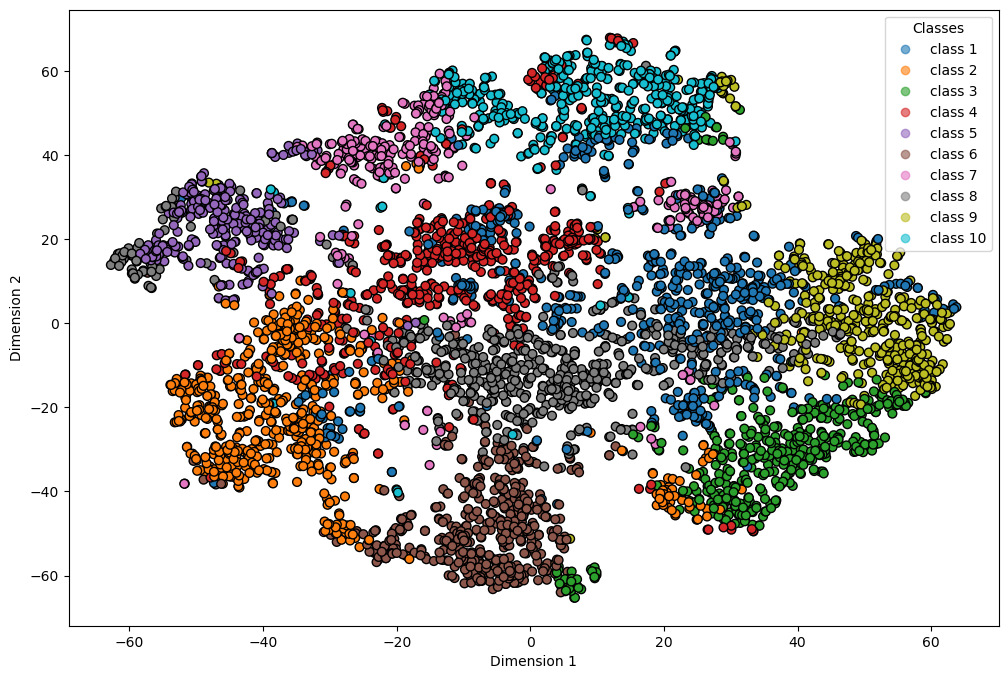

In [84]:
plot_list = []
plot_list.extend(extract_bottom_n_embeddings(500, 10, input_embeds))
plot_list.extend(extract_top_n_embeddings(500, 10, input_embeds))

exp = []
for i in range(500):
    for j in range(10):
        exp.append(plot_list[i][j])

cls_list, preds_list = extract_cls_token(model, exp, device)
visualize_embeddings(cls_list, preds_list, 10, random_state=42)

In [85]:
def visualize_embeddings_PCA(original_cls_token_list, predict_token_list, class_num, random_state=42):    
    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(original_cls_token_list)
    
    # 시각화: 클래스별로 색깔이 구분되도록 함
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=predict_token_list, cmap='tab10', edgecolor='k', s=40)
    
    # 범례 생성
    handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
    legend_labels = [f"class {i+1}" for i in range(class_num)]
    legend = plt.legend(handles, legend_labels, title="Classes")
    
    # 제목 및 축 레이블 설정
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    
    # 시각화 출력
    plt.show()

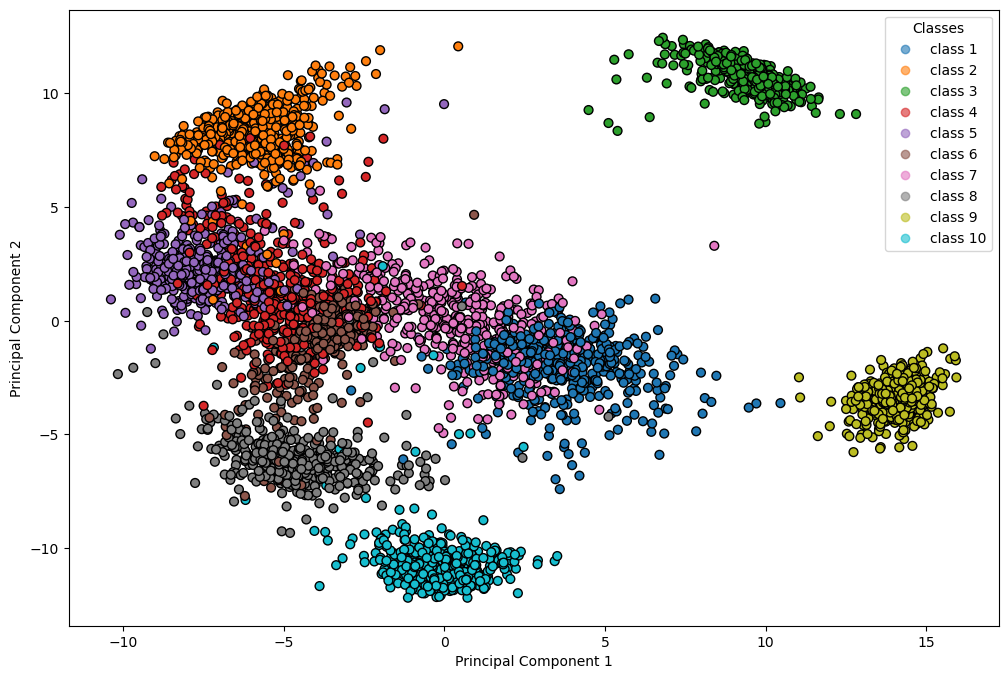

In [93]:
# PCA 시각화 결과
cls_list, preds_list = extract_cls_token(model, exp, device)
visualize_embeddings_PCA(cls_list, preds_list, 10, random_state=42)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


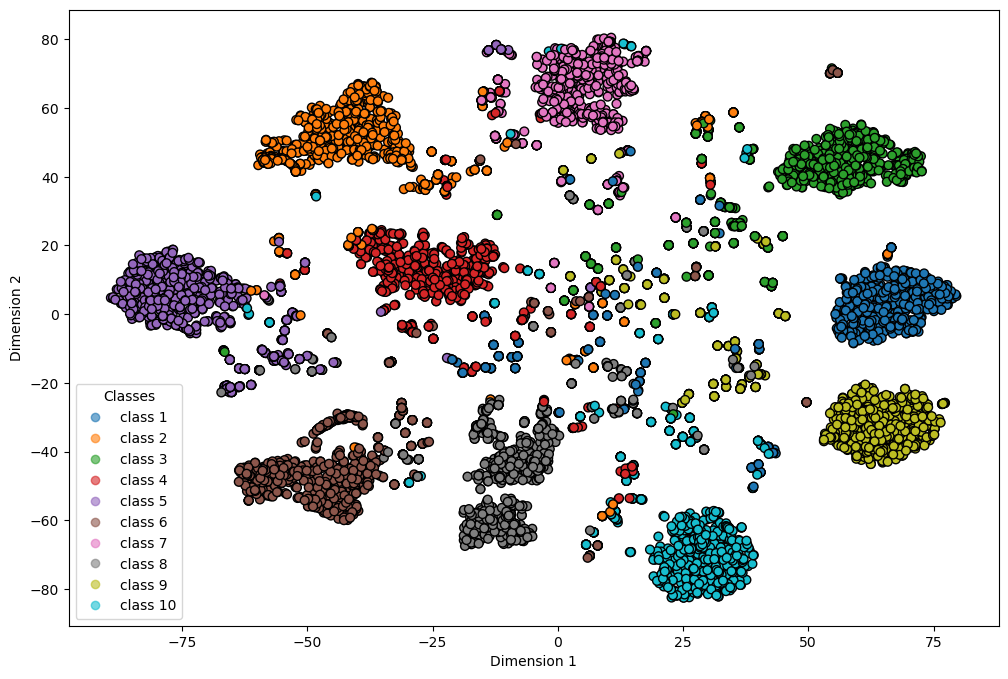

In [33]:
# top 4 mesuare 1
all_list = exp + positive_example_list+negative_example_list
cls_list, preds_list = extract_cls_token(model, all_list, device)
visualize_embeddings(cls_list, preds_list, 10, random_state=42)

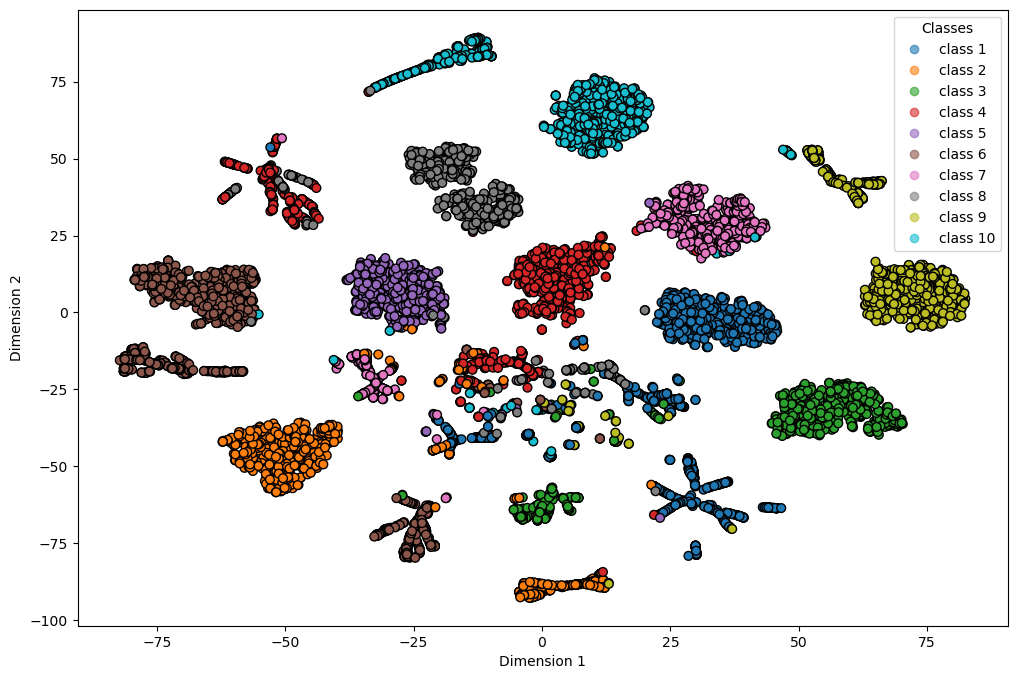

In [35]:
# bottom 4 mesuare 2
all_list = exp + positive_example_list+negative_example_list
cls_list, preds_list = extract_cls_token(model, all_list, device)
visualize_embeddings(cls_list, preds_list, 10, random_state=42)

In [23]:
input_embeds.shape

AttributeError: 'list' object has no attribute 'shape'